# Gaze and Pose-Based Interaction

Work by Antonio Vila Leis and Enric Baixauli Casañ

In [166]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import scipy.io as sio
import torchvision.transforms as T
from torch.utils.data import DataLoader
import cv2
import numpy as np
from models import utils
import sys
import matplotlib.pyplot as plt


In [2]:
if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
device = torch.device(device_name)
print(f"Code runs in {device}")

Code runs in cuda


In [3]:
class LP300W(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform

        self.img_paths = []
        self.mat_paths = []

        for folder in os.listdir(root):
            fpath = os.path.join(root, folder)
            if not os.path.isdir(fpath):
                continue

            for file in os.listdir(fpath):
                if file.endswith(".jpg"):
                    img_path = os.path.join(fpath, file)
                    mat_path = img_path.replace(".jpg", ".mat")

                    if os.path.exists(mat_path):
                        self.img_paths.append(img_path)
                        self.mat_paths.append(mat_path)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        mat = sio.loadmat(self.mat_paths[idx])

        pose = torch.tensor(mat["Pose_Para"][0][:3], dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        return img, pose


In [4]:
dataset = LP300W(
    root="dataset/300W_LP",
    transform=T.ToTensor()
)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

img, pose = next(iter(loader))
print(img.shape, pose.shape)


torch.Size([32, 3, 450, 450]) torch.Size([32, 3])


In [5]:
sys.path.append("./models")

from model import TokenHPE

model = TokenHPE(depth=3)
checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")

state_dict = checkpoint["model_state_dict"]

model.load_state_dict(state_dict, strict=True)
model.eval()



/home/anton/miniconda3/envs/cv2-2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


==> Add Sine PositionEmbedding~


/tmp/ipykernel_36749/4202605833.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("./weights/TokenHPEv1-ViTB-224_224-lyr3.tar", map_location="cpu")

TokenHPE(
  (feature_extractor): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )

In [6]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
    # T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

from PIL import Image
import torch

img_path = "dataset/300W_LP/AFW/AFW_134212_1_0.jpg"   # posa la que vulgues

img = Image.open(img_path).convert("RGB")
x = transform(img).unsqueeze(0)

with torch.no_grad():
    pred_rotation_matrix, ori_9_d = model(x)

print("Predicted Rotation Matrix Shape:", pred_rotation_matrix.shape)
print("Predicted Rotation Matrix:\n", pred_rotation_matrix[0])



Predicted Rotation Matrix Shape: torch.Size([1, 3, 3])
Predicted Rotation Matrix:
 tensor([[ 0.8834, -0.0207,  0.4681],
        [-0.1215,  0.9548,  0.2714],
        [-0.4525, -0.2967,  0.8410]])


In [7]:
# %run inference.py --model_path ./weights/TokenHPEv1-ViTB-224_224-lyr3.tar --image_path dataset/300W_LP/AFW/AFW_134212_1_0.jpg --save_path output.png

In [ ]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
    # T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


img_path = "dataset/300W_LP/AFW/AFW_134212_1_6.jpg"   

img = Image.open(img_path).convert("RGB")
x = transform(img).unsqueeze(0)

with torch.no_grad():
    pred_rotation_matrix, ori_9_d = model(x)

print("Predicted Rotation Matrix Shape:", pred_rotation_matrix.shape)
print("Predicted Rotation Matrix:\n", pred_rotation_matrix[0])

euler = utils.compute_euler_angles_from_rotation_matrices(pred_rotation_matrix) * 180 / np.pi
pitch = float(euler[0, 0])
yaw   = float(euler[0, 1])
roll  = float(euler[0, 2])

print("Pitch:", pitch, "Yaw:", yaw, "Roll:", roll)

cv_img = cv2.imread(img_path)

utils.draw_axis(cv_img, yaw, pitch, roll, size=100)

cv2.imshow("Pose", cv_img)
cv2.waitKey(0)
cv2.destroyAllWindows()


Predicted Rotation Matrix Shape: torch.Size([1, 3, 3])
Predicted Rotation Matrix:
 tensor([[ 0.5858, -0.0957,  0.8048],
        [-0.0781,  0.9817,  0.1736],
        [-0.8067, -0.1646,  0.5676]])
Pitch: -16.16709327697754 Yaw: 53.772430419921875 Roll: -7.592999458312988


# Data augmentation

In [167]:
JAW      = slice(0, 17)
EYEBROWS = slice(17, 27)
NOSE     = slice(27, 36)
EYES     = slice(36, 48)
MOUTH    = slice(48, 68)

def extract_landmarks(ruta_imagen):
    photo_name = os.path.splitext(os.path.basename(ruta_imagen))[0]
    folder = os.path.basename(os.path.dirname(ruta_imagen))
    ruta_mat = f"./dataset/300W_LP/landmarks/{folder}/{photo_name}_pts.mat"
    
    if not os.path.exists(ruta_mat):
        raise FileNotFoundError(f"Error: No landmarks found for: {ruta_mat}")

    mat_data = sio.loadmat(ruta_mat)

    if 'pts_2d' in mat_data:
        landmarks = mat_data['pts_2d']
    else:
        raise ValueError(f"Error: No landmarks found for: {ruta_mat}")

    return landmarks.astype(np.int32)

test_images = [f"./dataset/300W_LP/AFW/AFW_134212_1_{i}.jpg" for i in range(12)]

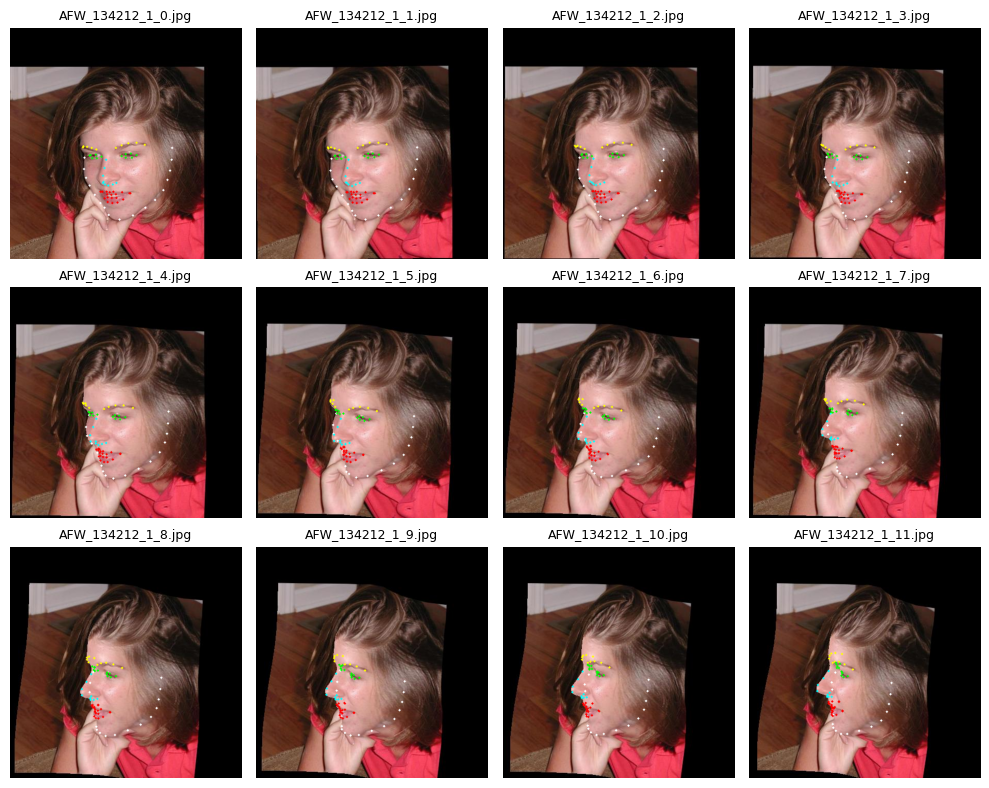

In [168]:
colors = {
    "Jaw": (JAW, 255, 255, 255),
    "Eyebrows": (EYEBROWS, 255, 255, 0),
    "Nose": (NOSE, 0, 255, 255),
    "Eyes": (EYES, 0, 255, 0),
    "Mouth": (MOUTH, 255, 0, 0)
}

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

for idx, test_image in enumerate(test_images):
    img = cv2.imread(test_image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    landmarks = extract_landmarks(test_image)
    img_points = img.copy()

    for name, (part, r, g, b) in colors.items():
        points = landmarks[part]
        for x, y in points:
            cv2.circle(img_points, (x, y), radius=2, color=(r, g, b), thickness=-1)

    axes[idx].imshow(img_points)
    axes[idx].set_title(os.path.basename(test_image), fontsize=9)
    axes[idx].axis('off')

for idx in range(len(test_images), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [169]:
def apply_occlusion(img, landmarks, mode="random"):
    """
    mode can be: 'random', 'clean', 'mask', or 'glasses'
    """
    img_occluded = img.copy()
    
    if mode == "random":
        choice = np.random.choice(["clean", "mask", "glasses"], p=[0.34, 0.33, 0.33])
    else:
        choice = mode
        
    if choice == "clean":
        return img_occluded
        
    elif choice == "mask":
        jaw_points = landmarks[2:15]
        nose_points = landmarks[29:31] 
        
        mask_points = np.vstack((jaw_points, nose_points))
        
        hull = cv2.convexHull(mask_points)
        
        cv2.fillPoly(img_occluded, [hull], (0, 0, 0))
        
    elif choice == "glasses":
        left_eye = landmarks[36:42]
        right_eye = landmarks[42:48]
        
        left_hull = cv2.convexHull(left_eye)
        right_hull = cv2.convexHull(right_eye)
        
        cv2.fillPoly(img_occluded, [left_hull], (0, 0, 0))
        cv2.fillPoly(img_occluded, [right_hull], (0, 0, 0))
        
        expansion_thickness = 25
        cv2.polylines(img_occluded, [left_hull], isClosed=True, color=(0, 0, 0), thickness=expansion_thickness)
        cv2.polylines(img_occluded, [right_hull], isClosed=True, color=(0, 0, 0), thickness=expansion_thickness)
        
        pt1 = tuple(landmarks[39])
        pt2 = tuple(landmarks[42])
        cv2.line(img_occluded, pt1, pt2, (0, 0, 0), thickness=8)

    # TODO: delete
    # for idx, point in enumerate(landmarks):
    #     cv2.circle(img_occluded, tuple(point), 2, (0, 255, 0), -1)
    #     #mostrar texto con el indice del punto
    #     cv2.putText(img_occluded, str(idx), tuple(point), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (255, 0, 0), 1)

    return img_occluded

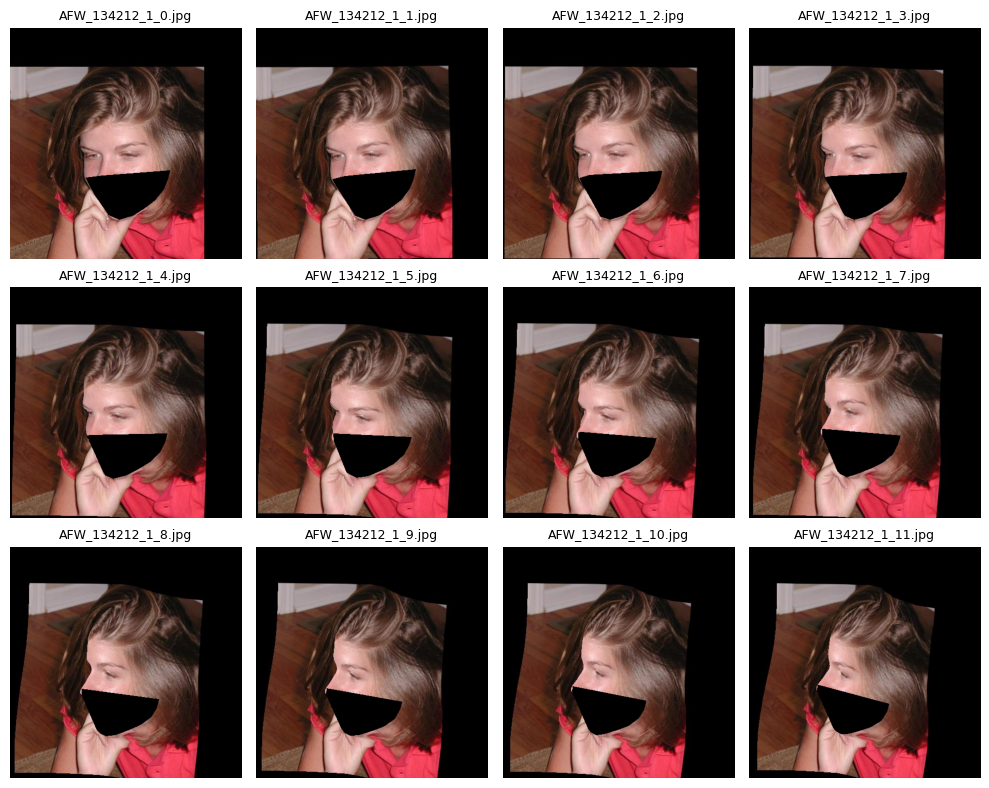

In [170]:
img = cv2.imread(test_image)

test_images = [f"./dataset/300W_LP/AFW/AFW_134212_1_{i}.jpg" for i in range(12)]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

for idx, test_image in enumerate(test_images):
    img = cv2.imread(test_image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    landmarks = extract_landmarks(test_image)
    occluded_img = apply_occlusion(img, landmarks, mode="mask")

    axes[idx].imshow(occluded_img)
    axes[idx].set_title(os.path.basename(test_image), fontsize=9)
    axes[idx].axis('off')

for idx in range(len(test_images), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

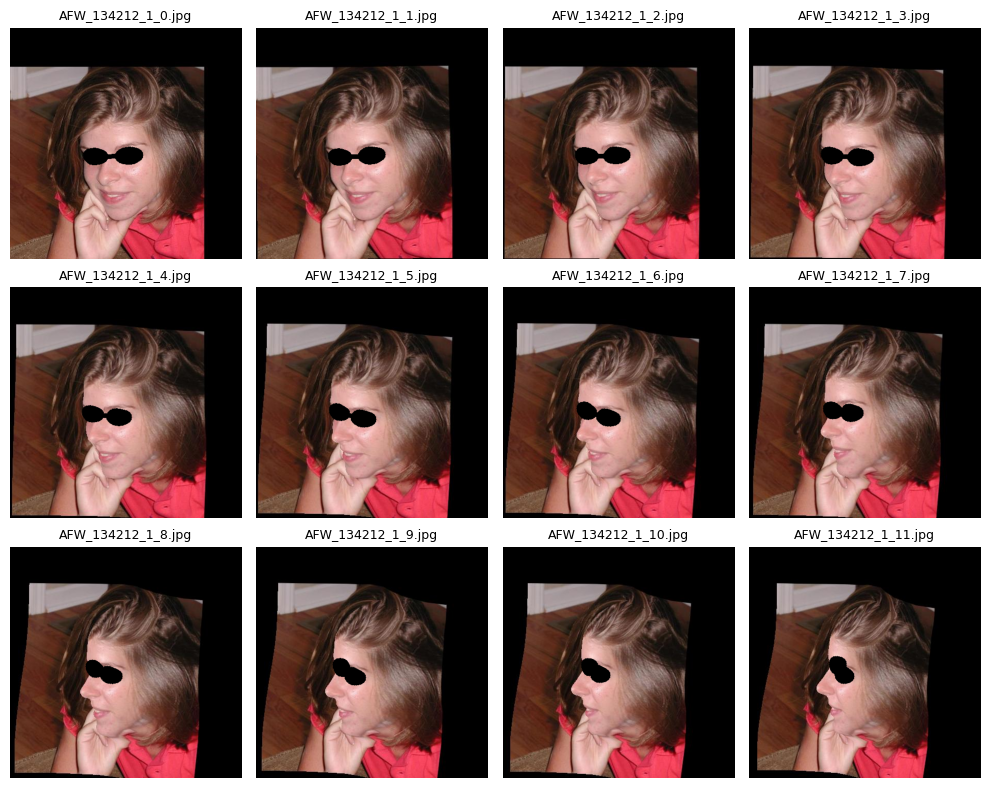

In [171]:
img = cv2.imread(test_image)

test_images = [f"./dataset/300W_LP/AFW/AFW_134212_1_{i}.jpg" for i in range(12)]

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

for idx, test_image in enumerate(test_images):
    img = cv2.imread(test_image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    landmarks = extract_landmarks(test_image)
    occluded_img = apply_occlusion(img, landmarks, mode="glasses")

    axes[idx].imshow(occluded_img)
    axes[idx].set_title(os.path.basename(test_image), fontsize=9)
    axes[idx].axis('off')

for idx in range(len(test_images), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()